# Quantum Cryptanalysis: Demonstrating SHA-256 Quantum Resistance
# Using Grover's Algorithm

---

**Team Members:** Aayush Patel & Dhwani Patel

**Course:** CPSC 4110 Quantum Algorithms

**Date:** 5th Dec, 2025


---
## Project Overview
---
#### This research we are demonstrating the post-quantum threats to current & older cryptographic algorithms
---
#### This notebook demonstrates quantum cryptanalysis using Grover's search algorithm applied to hash function preimage attacks. We show that while Grover's algorithm provides a genuine quadratic speedup over classical brute-force, SHA-256 remains secure against quantum attacks due to the astronomical computational requirements.
---
**Key Objectives:**
1. Implement Grover's algorithm from scratch
2. Attack hash functions of increasing complexity
3. Compare classical vs quantum search performance
4. Analyze noise impact using fake hardware backends
5. Extrapolate findings to real-world SHA-256 security
---

## Section 1: Environment Setup and Imports

In [189]:
# Install required packages
import subprocess
import sys

packages = ['qiskit', 'qiskit-aer', 'qiskit-ibm-runtime', 'matplotlib', 'numpy', 'pylatexenc']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('Package installation complete.')

Package installation complete.


In [190]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import time
import random
from typing import List, Tuple, Dict
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error

# Fake backend for realistic hardware simulation
from qiskit_ibm_runtime.fake_provider import FakeManilaV2, FakeJakartaV2

# Plotting configuration
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set random seed for reproducibility within a run, but different each execution
RANDOM_SEED = int(time.time()) % 10000
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f'Environment ready. Session seed: {RANDOM_SEED}')
print(f'This seed ensures results vary between runs while being reproducible within a session.')

Environment ready. Session seed: 4679
This seed ensures results vary between runs while being reproducible within a session.


## Section 2: Understanding the Problem - Hash Functions and Preimage Attacks

A **cryptographic hash function** takes an input of any size and produces a fixed-size output (the hash or digest). For SHA-256, the output is always 256 bits.

We have a hash (like "15"). We want to find what number created it.
That's basically impossible with regular computers - but quantum might help a bit.

**The Classical Way:** Check all one by one & random numbers until we get lucky. Takes forever.

**The Quantum Way:** Check all numbers at once using qubit's superposition & Grover's trick. Still takes forever but like... half as forever.

In [191]:
# Demonstrate real SHA-256 hashing
print('=' * 70)
print('REAL SHA-256 HASH FUNCTION DEMONSTRATION')
print('=' * 70)

test_inputs = ['hello', 'Hello', 'hello!', 'quantum']

print('\nSHA-256 produces 256-bit (64 hex character) outputs:')
print('-' * 70)
for inp in test_inputs:
    hash_result = hashlib.sha256(inp.encode()).hexdigest()
    print(f'Input: "{inp}"')
    print(f'SHA-256: {hash_result}')
    print()

print('Notice how even a single character change completely alters the hash.')
print('This is the "avalanche effect" - a key property of cryptographic hashes.')

REAL SHA-256 HASH FUNCTION DEMONSTRATION

SHA-256 produces 256-bit (64 hex character) outputs:
----------------------------------------------------------------------
Input: "hello"
SHA-256: 2cf24dba5fb0a30e26e83b2ac5b9e29e1b161e5c1fa7425e73043362938b9824

Input: "Hello"
SHA-256: 185f8db32271fe25f561a6fc938b2e264306ec304eda518007d1764826381969

Input: "hello!"
SHA-256: ce06092fb948d9ffac7d1a376e404b26b7575bcc11ee05a4615fef4fec3a308b

Input: "quantum"
SHA-256: 8fb7cf7a46995c95da6ad4cca750efb66946b771aca070d5948ea80ca33237b4

Notice how even a single character change completely alters the hash.
This is the "avalanche effect" - a key property of cryptographic hashes.


In [192]:
# Defining scalable hash functions for our experiments
# These simulate SHA-256 behavior at smaller scales we can actually attack

def hash_with_bits(data: int, output_bits: int) -> int:
    """
    Hash a number but only use the first few bits of the result.

    We use real SHA-256 but then cut it down to fit our quantum
    simulation (can't simulate 256 qubits on my laptop lol).

    Args:
        number: any integer we want to hash
        how_many_bits: like 4 or 6 bits for the output

    Returns:
        the truncated hash (just a number)
    """
    # Convert integer to bytes and hash with real SHA-256
    data_bytes = data.to_bytes((data.bit_length() + 7) // 8 or 1, 'big')
    full_hash = hashlib.sha256(data_bytes).digest()

    # Just grab the first part of the hash result (throw away the rest)
    hash_int = int.from_bytes(full_hash[:4], 'big')  # Take first 32 bits
    mask = (1 << output_bits) - 1
    return hash_int & mask


def analyze_hash_distribution(num_bits: int, input_space: int = None):
    """
    Analyze the distribution of a truncated hash function.
    Shows how inputs map to outputs (collision analysis).
    """
    if input_space is None:
        input_space = 2 ** num_bits

    output_space = 2 ** num_bits
    hash_counts = Counter()
    inputs_per_hash = {i: [] for i in range(output_space)}

    for x in range(input_space):
        h = hash_with_bits(x, num_bits)
        hash_counts[h] += 1
        inputs_per_hash[h].append(x)

    return hash_counts, inputs_per_hash


# Demonstrate with 4-bit hash
print('=' * 70)
print('TRUNCATED SHA-256 HASH FUNCTION (4-bit output)')
print('=' * 70)
print('\nThis uses real SHA-256 internally, truncated for quantum simulation.')
print('\nSample mappings (input -> 4-bit hash):')
print('-' * 40)

for i in range(16):
    h = hash_with_bits(i, 4)
    print(f'  {i:2d} (0b{i:04b}) -> {h:2d} (0b{h:04b})')

# Analyze distribution
counts_4bit, inputs_per_hash_4bit = analyze_hash_distribution(4, 16)
print(f'\nHash output distribution:')
for h in range(16):
    if inputs_per_hash_4bit[h]:
        print(f'  Hash {h:2d}: {len(inputs_per_hash_4bit[h])} preimage(s) = {inputs_per_hash_4bit[h]}')


TRUNCATED SHA-256 HASH FUNCTION (4-bit output)

This uses real SHA-256 internally, truncated for quantum simulation.

Sample mappings (input -> 4-bit hash):
----------------------------------------
   0 (0b0000) -> 12 (0b1100)
   1 (0b0001) -> 15 (0b1111)
   2 (0b0010) ->  9 (0b1001)
   3 (0b0011) ->  8 (0b1000)
   4 (0b0100) ->  0 (0b0000)
   5 (0b0101) -> 10 (0b1010)
   6 (0b0110) ->  8 (0b1000)
   7 (0b0111) ->  8 (0b1000)
   8 (0b1000) ->  9 (0b1001)
   9 (0b1001) -> 15 (0b1111)
  10 (0b1010) ->  9 (0b1001)
  11 (0b1011) ->  0 (0b0000)
  12 (0b1100) ->  1 (0b0001)
  13 (0b1101) -> 13 (0b1101)
  14 (0b1110) ->  7 (0b0111)
  15 (0b1111) ->  6 (0b0110)

Hash output distribution:
  Hash  0: 2 preimage(s) = [4, 11]
  Hash  1: 1 preimage(s) = [12]
  Hash  6: 1 preimage(s) = [15]
  Hash  7: 1 preimage(s) = [14]
  Hash  8: 3 preimage(s) = [3, 6, 7]
  Hash  9: 3 preimage(s) = [2, 8, 10]
  Hash 10: 1 preimage(s) = [5]
  Hash 12: 1 preimage(s) = [0]
  Hash 13: 1 preimage(s) = [13]
  Hash 15: 

## Section 3: Grover's Algorithm Implementation

Grover's algorithm consists of:
1. **Initialization:** Create uniform superposition over all states
2. **Oracle:** Mark target state(s) by flipping their phase
3. **Diffusion:** Amplify marked states, suppress others
4. **Iteration:** Repeat oracle+diffusion approximately sqrt(N) times
5. **Measurement:** Collapse to target with high probability

In [193]:
class GroverOracle:
    """
    The oracle - Marks our target answers by basically flipping the phase of the states which are bruteforced properly & we can
    amplify them later. That's it.
    """

    def __init__(self, num_qubits: int, targets: List[int]):
        """
        Args:
            num_qubits: Number of qubits in the search space
            targets: List of target states (as integers)
        """
        self.num_qubits = num_qubits
        self.targets = targets

    def build(self) -> QuantumCircuit:
        """Build the oracle circuit."""
        oracle = QuantumCircuit(self.num_qubits, name='Oracle')

        for target in self.targets:
            # Convert target to binary and determine which qubits need X gates
            target_bits = format(target, f'0{self.num_qubits}b')

            # Apply X gates to qubits that should be |0> in target
            for i, bit in enumerate(reversed(target_bits)):
                if bit == '0':
                    oracle.x(i)

            # Multi-controlled Z gate (phase flip when all qubits are |1>)
            if self.num_qubits == 1:
                oracle.z(0)
            elif self.num_qubits == 2:
                oracle.cz(0, 1)
            else:
                # Implement multi-controlled Z using H-MCX-H
                oracle.h(self.num_qubits - 1)
                oracle.mcx(list(range(self.num_qubits - 1)), self.num_qubits - 1)
                oracle.h(self.num_qubits - 1)

            # Undo X gates
            for i, bit in enumerate(reversed(target_bits)):
                if bit == '0':
                    oracle.x(i)

        return oracle


class GroverDiffusion:
    """
    Diffusion operator for Grover's algorithm.
    Implements: D = 2|s><s| - I where |s> is uniform superposition.
    """

    def __init__(self, num_qubits: int):
        self.num_qubits = num_qubits

    def build(self) -> QuantumCircuit:
        """Build the diffusion circuit."""
        diffusion = QuantumCircuit(self.num_qubits, name='Diffusion')

        # Apply H gates to move to computational basis
        diffusion.h(range(self.num_qubits))

        # Apply X gates
        diffusion.x(range(self.num_qubits))

        # Multi-controlled Z
        if self.num_qubits == 1:
            diffusion.z(0)
        elif self.num_qubits == 2:
            diffusion.cz(0, 1)
        else:
            diffusion.h(self.num_qubits - 1)
            diffusion.mcx(list(range(self.num_qubits - 1)), self.num_qubits - 1)
            diffusion.h(self.num_qubits - 1)

        # Undo X and H
        diffusion.x(range(self.num_qubits))
        diffusion.h(range(self.num_qubits))

        return diffusion


class GroverSearch:
    """
    Complete Grover's search algorithm implementation.
    """

    def __init__(self, num_qubits: int, targets: List[int]):
        """
        Args:
            num_qubits: Size of search space (2^num_qubits states)
            targets: List of target states to find
        """
        self.num_qubits = num_qubits
        self.targets = targets
        self.search_space_size = 2 ** num_qubits
        self.n_targets = len(targets)
        self.optimal_iterations = self._calculate_optimal_iterations()

        # Build components
        self.oracle = GroverOracle(num_qubits, targets).build()
        self.diffusion = GroverDiffusion(num_qubits).build()

    def _calculate_optimal_iterations(self) -> int:
        """Calculate optimal number of Grover iterations."""
        # Formula: k = round(pi/4 * sqrt(N/M))
        N = self.search_space_size
        M = self.n_targets
        optimal = int(np.round((np.pi / 4) * np.sqrt(N / M)))
        return max(1, optimal)

    def build_circuit(self, iterations: int = None) -> QuantumCircuit:
        """Build complete Grover circuit."""
        if iterations is None:
            iterations = self.optimal_iterations

        qr = QuantumRegister(self.num_qubits, 'q')
        cr = ClassicalRegister(self.num_qubits, 'c')
        circuit = QuantumCircuit(qr, cr)

        # Step 1: Initialize uniform superposition
        circuit.h(range(self.num_qubits))
        circuit.barrier(label='Init')

        # Step 2: Apply Grover iterations
        for i in range(iterations):
            circuit.compose(self.oracle, inplace=True)
            circuit.compose(self.diffusion, inplace=True)
            if i < iterations - 1:  # Don't add barrier after last iteration
                circuit.barrier(label=f'Iter {i+1}')

        circuit.barrier(label='Measure')

        # Step 3: Measure
        circuit.measure(qr, cr)

        return circuit

    def theoretical_success_probability(self, iterations: int = None) -> float:
        """Calculate theoretical success probability."""
        if iterations is None:
            iterations = self.optimal_iterations

        N = self.search_space_size
        M = self.n_targets
        theta = np.arcsin(np.sqrt(M / N))
        prob = np.sin((2 * iterations + 1) * theta) ** 2
        return prob


print('Grover algorithm classes defined successfully.')


Grover algorithm classes defined successfully.


## Section 4: Classical vs Quantum Search - Direct Comparison

In [194]:
def classical_brute_force_search(search_space: int, targets: List[int],
                                  max_attempts: int = None) -> Tuple[int, bool, int]:
    """
    Simulate classical brute-force search.

    Args:
        search_space: Size of search space
        targets: List of valid targets
        max_attempts: Maximum attempts (default: search entire space)

    Returns:
        (found_value, success, attempts_made)
    """
    if max_attempts is None:
        max_attempts = search_space

    # Randomize search order (simulates unstructured search)
    search_order = list(range(search_space))
    random.shuffle(search_order)

    for i, candidate in enumerate(search_order[:max_attempts]):
        if candidate in targets:
            return candidate, True, i + 1

    return -1, False, max_attempts


def run_quantum_search(grover: GroverSearch, shots: int = 1024,
                       backend=None) -> Tuple[Dict, float, int]:
    """
    Run Grover's algorithm and return results.

    Returns:
        (counts_dict, success_rate, circuit_depth)
    """
    circuit = grover.build_circuit()

    if backend is None:
        backend = AerSimulator()

    # Transpile for backend
    transpiled = transpile(circuit, backend, optimization_level=1)

    # Run
    job = backend.run(transpiled, shots=shots)
    counts = job.result().get_counts()

    # Calculate success rate
    target_strs = [format(t, f'0{grover.num_qubits}b') for t in grover.targets]
    success_count = sum(counts.get(t, 0) for t in target_strs)
    success_rate = success_count / shots

    return counts, success_rate, transpiled.depth()


print('Search functions defined.')


Search functions defined.


In [195]:
# Experiment: Compare classical vs quantum search across different problem sizes

print('=' * 70)
print('EXPERIMENT: CLASSICAL VS QUANTUM SEARCH COMPARISON')
print('=' * 70)

comparison_results = []
n_classical_trials = 100  # Average over multiple trials for classical

for num_qubits in [3, 4, 5]:
    search_space = 2 ** num_qubits

    # Generate random target (different each run due to seed)
    target = random.randint(0, search_space - 1)

    print(f'\n{"="*60}')
    print(f'{num_qubits}-QUBIT SEARCH SPACE ({search_space} states)')
    print(f'Target: {target} (binary: {format(target, f"0{num_qubits}b")})')
    print('=' * 60)

    # Classical search (average over trials)
    classical_attempts = []
    for _ in range(n_classical_trials):
        _, _, attempts = classical_brute_force_search(search_space, [target])
        classical_attempts.append(attempts)

    avg_classical = np.mean(classical_attempts)
    theoretical_classical = search_space / 2  # Expected value for uniform search

    # Quantum search
    grover = GroverSearch(num_qubits, [target])
    counts, success_rate, depth = run_quantum_search(grover, shots=1024)

    # Results
    print(f'\nCLASSICAL BRUTE FORCE:')
    print(f'  Theoretical average attempts: {theoretical_classical:.1f}')
    print(f'  Measured average ({n_classical_trials} trials): {avg_classical:.1f}')
    print(f'  Worst case: {search_space}')

    print(f'\nQUANTUM (GROVER):')
    print(f'  Optimal iterations: {grover.optimal_iterations}')
    print(f'  Theoretical success probability: {grover.theoretical_success_probability():.1%}')
    print(f'  Measured success rate: {success_rate:.1%}')
    print(f'  Circuit depth: {depth}')

    # Speedup calculation
    quantum_queries = grover.optimal_iterations
    speedup = theoretical_classical / quantum_queries
    print(f'\nSPEEDUP: {speedup:.1f}x fewer queries than classical average')

    comparison_results.append({
        'num_qubits': num_qubits,
        'search_space': search_space,
        'target': target,
        'classical_avg': avg_classical,
        'quantum_iters': grover.optimal_iterations,
        'quantum_success': success_rate,
        'speedup': speedup
    })


EXPERIMENT: CLASSICAL VS QUANTUM SEARCH COMPARISON

3-QUBIT SEARCH SPACE (8 states)
Target: 5 (binary: 101)

CLASSICAL BRUTE FORCE:
  Theoretical average attempts: 4.0
  Measured average (100 trials): 4.7
  Worst case: 8

QUANTUM (GROVER):
  Optimal iterations: 2
  Theoretical success probability: 94.5%
  Measured success rate: 95.7%
  Circuit depth: 12

SPEEDUP: 2.0x fewer queries than classical average

4-QUBIT SEARCH SPACE (16 states)
Target: 11 (binary: 1011)

CLASSICAL BRUTE FORCE:
  Theoretical average attempts: 8.0
  Measured average (100 trials): 8.6
  Worst case: 16

QUANTUM (GROVER):
  Optimal iterations: 3
  Theoretical success probability: 96.1%
  Measured success rate: 96.0%
  Circuit depth: 17

SPEEDUP: 2.7x fewer queries than classical average

5-QUBIT SEARCH SPACE (32 states)
Target: 2 (binary: 00010)

CLASSICAL BRUTE FORCE:
  Theoretical average attempts: 16.0
  Measured average (100 trials): 15.6
  Worst case: 32

QUANTUM (GROVER):
  Optimal iterations: 4
  Theoretica

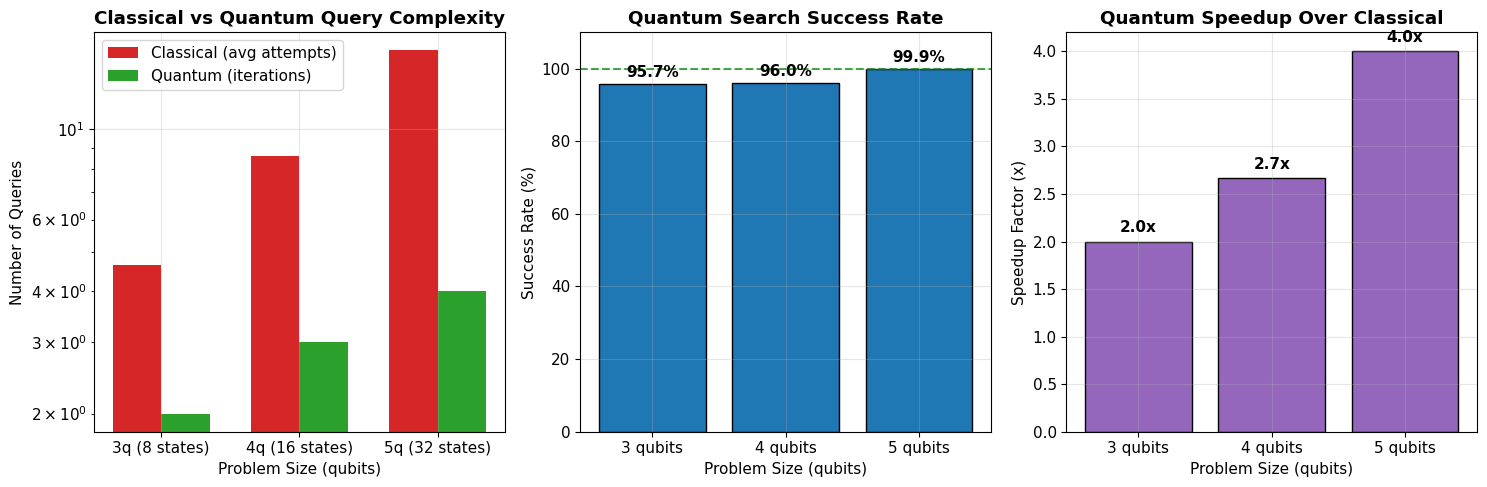

Figure saved: classical_vs_quantum_comparison.png


In [196]:
# Visualize the comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

num_qubits_list = [r['num_qubits'] for r in comparison_results]
search_spaces = [r['search_space'] for r in comparison_results]
classical_avgs = [r['classical_avg'] for r in comparison_results]
quantum_iters = [r['quantum_iters'] for r in comparison_results]
quantum_success = [r['quantum_success'] * 100 for r in comparison_results]

# Plot 1: Query complexity comparison
ax1 = axes[0]
x = np.arange(len(num_qubits_list))
width = 0.35
bars1 = ax1.bar(x - width/2, classical_avgs, width, label='Classical (avg attempts)', color='#d62728')
bars2 = ax1.bar(x + width/2, quantum_iters, width, label='Quantum (iterations)', color='#2ca02c')
ax1.set_xlabel('Problem Size (qubits)')
ax1.set_ylabel('Number of Queries')
ax1.set_title('Classical vs Quantum Query Complexity', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{n}q ({2**n} states)' for n in num_qubits_list])
ax1.legend()
ax1.set_yscale('log')

# Plot 2: Quantum success rates
ax2 = axes[1]
ax2.bar(x, quantum_success, color='#1f77b4', edgecolor='black')
ax2.axhline(y=100, color='green', linestyle='--', alpha=0.7, label='Perfect success')
ax2.set_xlabel('Problem Size (qubits)')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Quantum Search Success Rate', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{n} qubits' for n in num_qubits_list])
ax2.set_ylim(0, 110)
for i, v in enumerate(quantum_success):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 3: Speedup factor
ax3 = axes[2]
speedups = [r['speedup'] for r in comparison_results]
ax3.bar(x, speedups, color='#9467bd', edgecolor='black')
ax3.set_xlabel('Problem Size (qubits)')
ax3.set_ylabel('Speedup Factor (x)')
ax3.set_title('Quantum Speedup Over Classical', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{n} qubits' for n in num_qubits_list])
for i, v in enumerate(speedups):
    ax3.text(i, v + 0.1, f'{v:.1f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('classical_vs_quantum_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: classical_vs_quantum_comparison.png')


## Section 5: Hash Function Preimage Attack Demonstration

## Let's Actually Attack a Hash

We're going to:
1. Pick a random number
2. Hash it to get a target value
3. Use Grover to find what number makes that hash
4. See if it actually works


In [197]:
def find_preimages(target_hash: int, n_bits: int, input_space: int) -> List[int]:
    """
    Find all preimages that hash to the target value.
    (Classical exhaustive search for verification)
    """
    preimages = []
    for x in range(input_space):
        if truncated_sha256(x, n_bits) == target_hash:
            preimages.append(x)
    return preimages


# Experiment 1: Small scale (4-bit hash, quick verification)
print('=' * 70)
print('EXPERIMENT: QUANTUM PREIMAGE ATTACK ON 4-BIT TRUNCATED SHA-256')
print('=' * 70)

n_bits_small = 4
input_space_small = 16  # 2^4 possible inputs

# Generate random target hash (changes each run)
random_input = random.randint(0, input_space_small - 1)
target_hash_small = truncated_sha256(random_input, n_bits_small)

print(f'\nTarget hash: {target_hash_small} (binary: {format(target_hash_small, f"0{n_bits_small}b")})')
print(f'Generated from random input: {random_input}')

# Find all preimages classically (for verification)
preimages_small = find_preimages(target_hash_small, n_bits_small, input_space_small)
print(f'\nClassical analysis found {len(preimages_small)} preimage(s): {preimages_small}')

# Quantum attack
print(f'\nRunning Grover search for preimages...')
grover_attack = GroverSearch(n_bits_small, preimages_small)
print(f'Optimal iterations: {grover_attack.optimal_iterations}')

counts_small, success_small, depth_small = run_quantum_search(grover_attack, shots=2048)

print(f'\nQuantum Attack Results:')
print(f'Circuit depth: {depth_small}')
print(f'Success rate: {success_small:.1%}')

print(f'\nMeasurement distribution (top 5):')
for state, count in sorted(counts_small.items(), key=lambda x: x[1], reverse=True)[:5]:
    decimal = int(state, 2)
    is_preimage = decimal in preimages_small
    marker = ' [PREIMAGE FOUND]' if is_preimage else ''
    print(f'  |{state}> (={decimal:2d}): {count:4d} ({100*count/2048:5.1f}%){marker}')

EXPERIMENT: QUANTUM PREIMAGE ATTACK ON 4-BIT TRUNCATED SHA-256

Target hash: 1 (binary: 0001)
Generated from random input: 12

Classical analysis found 1 preimage(s): [12]

Running Grover search for preimages...
Optimal iterations: 3

Quantum Attack Results:
Circuit depth: 17
Success rate: 95.9%

Measurement distribution (top 5):
  |1100> (=12): 1964 ( 95.9%) [PREIMAGE FOUND]
  |1101> (=13):   11 (  0.5%)
  |0001> (= 1):    9 (  0.4%)
  |1010> (=10):    8 (  0.4%)
  |1110> (=14):    7 (  0.3%)


In [198]:
# Experiment 2: Larger scale (6-bit hash, more realistic)
print('=' * 70)
print('EXPERIMENT: QUANTUM PREIMAGE ATTACK ON 6-BIT TRUNCATED SHA-256')
print('=' * 70)

num_bits_large = 6
input_space_large = 64  # 2^6 possible inputs

# Generate random target hash
random_input_large = random.randint(0, input_space_large - 1)
target_hash_large = hash_with_bits(random_input_large, num_bits_large)

print(f'\nTarget hash: {target_hash_large} (binary: {format(target_hash_large, f"0{num_bits_large}b")})')
print(f'Search space: {input_space_large} possible inputs')

# Find preimages classically
found_inputs_large = find_preimages(target_hash_large, num_bits_large, input_space_large)
print(f'Classical analysis found {len(found_inputs_large)} preimage(s): {found_inputs_large}')

# Classical search timing
classical_times = []
for _ in range(50):
    start = time.time()
    _, _, attempts = classical_brute_force_search(input_space_large, found_inputs_large)
    classical_times.append(attempts)

print(f'\nClassical brute force (50 trials):')
print(f'  Average attempts: {np.mean(classical_times):.1f}')
print(f'  Theoretical average: {input_space_large / len(found_inputs_large) / 2:.1f}')

# Quantum attack
print(f'\nQuantum Grover attack:')
grover_large = GroverSearch(num_bits_large, found_inputs_large)
print(f'  Optimal iterations: {grover_large.optimal_iterations}')

counts_large, success_large, depth_large = run_quantum_search(grover_large, shots=2048)

print(f'  Circuit depth: {depth_large}')
print(f'  Success rate: {success_large:.1%}')
print(f'  Theoretical success: {grover_large.theoretical_success_probability():.1%}')

# Speedup
speedup_large = np.mean(classical_times) / grover_large.optimal_iterations
print(f'\nQuantum speedup: {speedup_large:.1f}x fewer queries')


EXPERIMENT: QUANTUM PREIMAGE ATTACK ON 6-BIT TRUNCATED SHA-256

Target hash: 57 (binary: 111001)
Search space: 64 possible inputs
Classical analysis found 3 preimage(s): [8, 35, 61]

Classical brute force (50 trials):
  Average attempts: 16.5
  Theoretical average: 10.7

Quantum Grover attack:
  Optimal iterations: 4
  Circuit depth: 38
  Success rate: 85.4%
  Theoretical success: 85.3%

Quantum speedup: 4.1x fewer queries


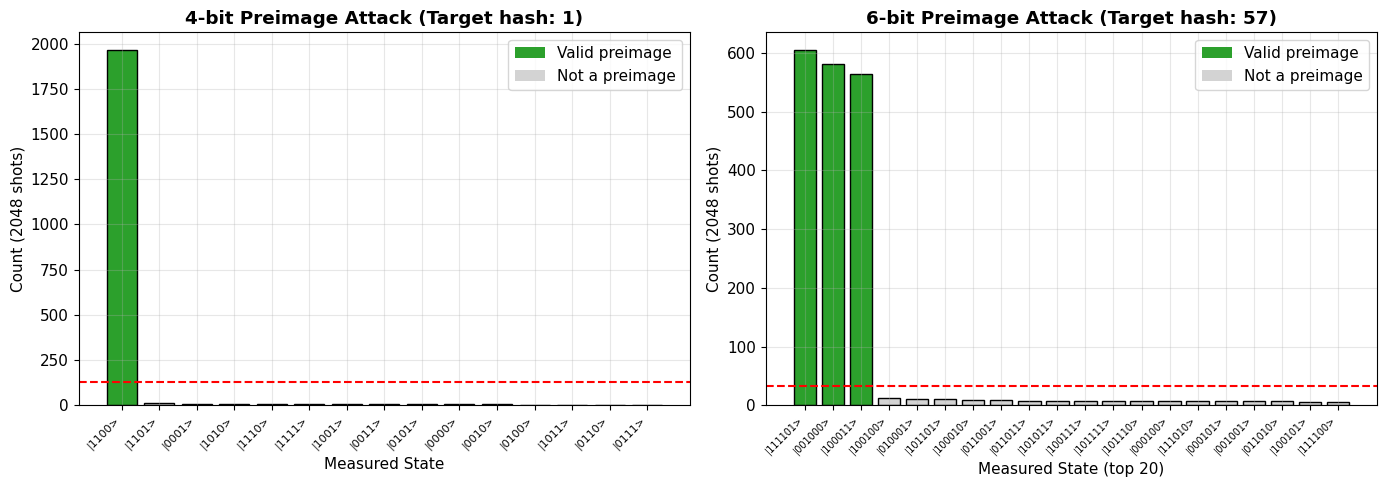

Figure saved: preimage_attack_results.png


In [199]:
# Visualize the preimage attack results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 4-bit attack results
ax1 = axes[0]
states_4 = list(counts_small.keys())
values_4 = [counts_small[s] for s in states_4]
colors_4 = ['#2ca02c' if int(s, 2) in preimages_small else '#d3d3d3' for s in states_4]

# Sort by value
sorted_idx = np.argsort(values_4)[::-1]
states_4_sorted = [states_4[i] for i in sorted_idx]
values_4_sorted = [values_4[i] for i in sorted_idx]
colors_4_sorted = [colors_4[i] for i in sorted_idx]

ax1.bar(range(len(states_4_sorted)), values_4_sorted, color=colors_4_sorted, edgecolor='black')
ax1.set_xticks(range(len(states_4_sorted)))
ax1.set_xticklabels([f'|{s}>' for s in states_4_sorted], rotation=45, ha='right', fontsize=8)
ax1.axhline(y=2048/16, color='red', linestyle='--', label=f'Random ({100/16:.1f}%)')
ax1.set_xlabel('Measured State')
ax1.set_ylabel('Count (2048 shots)')
ax1.set_title(f'4-bit Preimage Attack (Target hash: {target_hash_small})', fontweight='bold')
ax1.legend()

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='Valid preimage'),
                   Patch(facecolor='#d3d3d3', label='Not a preimage')]
ax1.legend(handles=legend_elements, loc='upper right')

# Right: 6-bit attack results
ax2 = axes[1]
states_6 = list(counts_large.keys())
values_6 = [counts_large[s] for s in states_6]
colors_6 = ['#2ca02c' if int(s, 2) in found_inputs_large else '#d3d3d3' for s in states_6]

sorted_idx = np.argsort(values_6)[::-1][:20]  # Show top 20
states_6_sorted = [states_6[i] for i in sorted_idx]
values_6_sorted = [values_6[i] for i in sorted_idx]
colors_6_sorted = [colors_6[i] for i in sorted_idx]

ax2.bar(range(len(states_6_sorted)), values_6_sorted, color=colors_6_sorted, edgecolor='black')
ax2.set_xticks(range(len(states_6_sorted)))
ax2.set_xticklabels([f'|{s}>' for s in states_6_sorted], rotation=45, ha='right', fontsize=7)
ax2.axhline(y=2048/64, color='red', linestyle='--', label=f'Random ({100/64:.1f}%)')
ax2.set_xlabel('Measured State (top 20)')
ax2.set_ylabel('Count (2048 shots)')
ax2.set_title(f'6-bit Preimage Attack (Target hash: {target_hash_large})', fontweight='bold')
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('preimage_attack_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: preimage_attack_results.png')

## Section 6: Grover Iteration Analysis

Grover's algorithm has oscillatory behavior - too few or too many iterations reduces success probability.

In [200]:
print('=' * 70)
print('EXPERIMENT: GROVER ITERATION OPTIMIZATION')
print('=' * 70)

num_qubits_iter = 5  # 32 states
target_iter = random.randint(0, 2**num_qubits_iter - 1)

print(f'\nSearch space: {2**num_qubits_iter} states')
print(f'Target: {target_iter} (binary: {format(target_iter, f"0{num_qubits_iter}b")})')

grover_iter = GroverSearch(num_qubits_iter, [target_iter])
optimal = grover_iter.optimal_iterations
print(f'Theoretical optimal iterations: {optimal}')

# Test different iteration counts
max_iters = 15
iteration_data = []

print(f'\n{"Iterations":<12} {"Success Rate":<15} {"Theoretical":<15} {"Status"}')
print('-' * 55)

for iters in range(1, max_iters + 1):
    circuit = grover_iter.build_circuit(iterations=iters)
    result = AerSimulator().run(circuit, shots=2048).result().get_counts()

    target_str = format(target_iter, f'0{num_qubits_iter}b')
    success = result.get(target_str, 0) / 2048
    theoretical = grover_iter.theoretical_success_probability(iters)

    status = 'OPTIMAL' if iters == optimal else ''
    print(f'{iters:<12} {success:>12.1%}   {theoretical:>12.1%}   {status}')

    iteration_data.append({
        'iterations': iters,
        'measured': success * 100,
        'theoretical': theoretical * 100
    })


EXPERIMENT: GROVER ITERATION OPTIMIZATION

Search space: 32 states
Target: 28 (binary: 11100)
Theoretical optimal iterations: 4

Iterations   Success Rate    Theoretical     Status
-------------------------------------------------------
1                   24.2%          25.8%   
2                   58.7%          60.2%   
3                   90.0%          89.7%   
4                  100.0%          99.9%   OPTIMAL
5                   85.0%          86.0%   
6                   56.8%          54.6%   
7                   22.5%          21.0%   
8                    0.9%           1.4%   
9                    5.3%           5.4%   
10                  31.2%          31.0%   
11                  63.3%          65.8%   
12                  92.5%          92.9%   
13                  99.3%          99.3%   
14                  82.5%          81.8%   
15                  48.2%          48.9%   


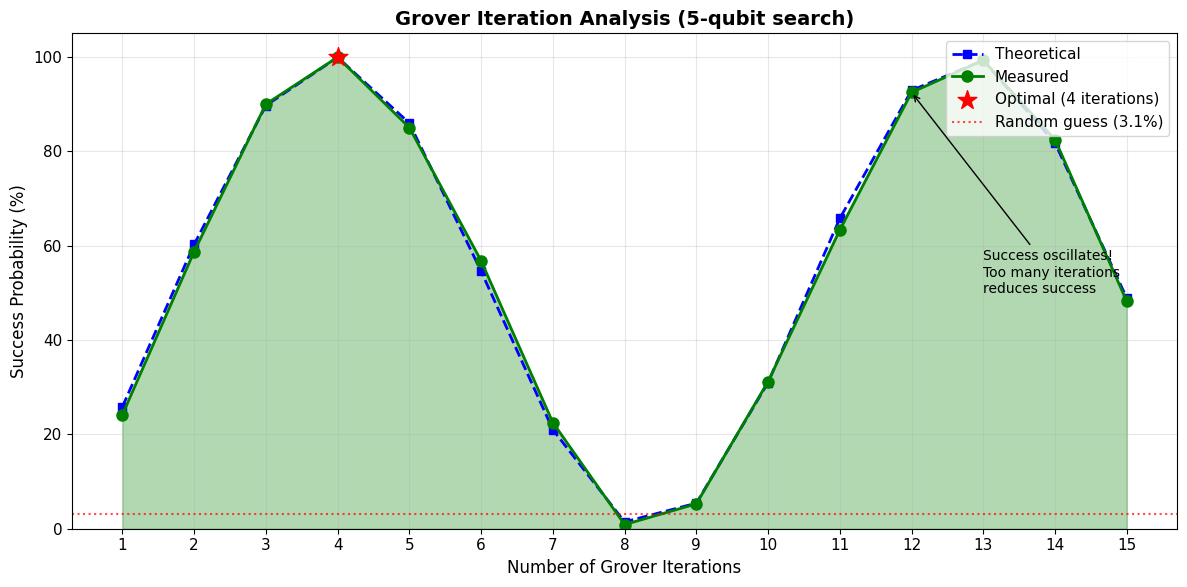

Figure saved: iteration_analysis.png


In [201]:
# Visualize iteration analysis
fig, ax = plt.subplots(figsize=(12, 6))

iters = [d['iterations'] for d in iteration_data]
measured = [d['measured'] for d in iteration_data]
theoretical = [d['theoretical'] for d in iteration_data]

ax.plot(iters, theoretical, 'b--', linewidth=2, label='Theoretical', marker='s', markersize=6)
ax.plot(iters, measured, 'go-', linewidth=2, label='Measured', marker='o', markersize=8)
ax.fill_between(iters, measured, alpha=0.3, color='green')

# Mark optimal
opt_idx = optimal - 1
ax.scatter([optimal], [measured[opt_idx]], color='red', s=200, zorder=5,
           label=f'Optimal ({optimal} iterations)', marker='*')

# Random baseline
random_prob = 100 / (2**num_qubits_iter)
ax.axhline(y=random_prob, color='red', linestyle=':', alpha=0.7,
           label=f'Random guess ({random_prob:.1f}%)')

ax.set_xlabel('Number of Grover Iterations', fontsize=12)
ax.set_ylabel('Success Probability (%)', fontsize=12)
ax.set_title(f'Grover Iteration Analysis ({num_qubits_iter}-qubit search)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xticks(iters)
ax.set_ylim(0, 105)

# Annotate oscillation
ax.annotate('Success oscillates!\nToo many iterations\nreduces success',
            xy=(12, measured[11]), xytext=(13, 50),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

plt.tight_layout()
plt.savefig('iteration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: iteration_analysis.png')


## Section 7: Noise Analysis - Ideal Simulator vs Fake Hardware

Real quantum computers have noise from gate errors, decoherence, and measurement errors. We compare:
1. Ideal simulator (no noise)
2. Custom noise model (configurable error rates)
3. FakeManila backend (realistic IBM hardware noise)

In [202]:
def create_custom_noise_model(single_qubit_error: float, two_qubit_error: float) -> NoiseModel:
    """
    Create a noise model with specified error rates.
    """
    noise_model = NoiseModel()

    # Single-qubit gate errors
    error_1q = depolarizing_error(single_qubit_error, 1)
    noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'z', 'sx', 'rz'])

    # Two-qubit gate errors
    error_2q = depolarizing_error(two_qubit_error, 2)
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'cz', 'ecr'])

    return noise_model


print('=' * 70)
print('EXPERIMENT: NOISE IMPACT ANALYSIS')
print('=' * 70)

# Use 4-qubit search for noise analysis (manageable but meaningful)
num_qubits_noise = 4
target_noise = random.randint(0, 2**num_qubits_noise - 1)

print(f'\nTest setup: {num_qubits_noise}-qubit search, target={target_noise}')

grover_noise = GroverSearch(num_qubits_noise, [target_noise])
circuit_noise = grover_noise.build_circuit()
target_str_noise = format(target_noise, f'0{num_qubits_noise}b')

print(f'Circuit depth: {circuit_noise.depth()}')
print(f'Gate count: {circuit_noise.size()}')

# Test environments
noise_results = []

# 1. Ideal simulator
print('\nRunning on ideal simulator...')
ideal_sim = AerSimulator()
ideal_circuit = transpile(circuit_noise, ideal_sim, optimization_level=1)
ideal_counts = ideal_sim.run(ideal_circuit, shots=4096).result().get_counts()
ideal_success = ideal_counts.get(target_str_noise, 0) / 4096
noise_results.append(('Ideal Simulator', 0, ideal_success, ideal_circuit.depth()))
print(f'  Success rate: {ideal_success:.1%}')

# 2. Custom noise models with varying error rates
error_rates = [0.001, 0.005, 0.01, 0.02, 0.05]
print('\nRunning with custom noise models...')

for error in error_rates:
    noise_model = create_custom_noise_model(error, error * 10)  # 2Q errors typically 10x worse
    noisy_sim = AerSimulator(noise_model=noise_model)
    noisy_circuit = transpile(circuit_noise, noisy_sim, optimization_level=1)
    noisy_counts = noisy_sim.run(noisy_circuit, shots=4096).result().get_counts()
    noisy_success = noisy_counts.get(target_str_noise, 0) / 4096
    noise_results.append((f'{error*100:.1f}% error', error, noisy_success, noisy_circuit.depth()))
    print(f'  {error*100:.1f}% gate error: {noisy_success:.1%} success')


EXPERIMENT: NOISE IMPACT ANALYSIS

Test setup: 4-qubit search, target=2
Circuit depth: 38
Gate count: 92

Running on ideal simulator...
  Success rate: 96.1%

Running with custom noise models...
  0.1% gate error: 47.7% success
  0.5% gate error: 7.6% success
  1.0% gate error: 6.4% success
  2.0% gate error: 6.4% success
  5.0% gate error: 6.4% success


In [203]:
# 3. FakeManila backend (realistic IBM hardware)
print('\nRunning on FakeManila (simulated IBM hardware)...')

fake_backend = FakeManilaV2()
print(f'  Backend: {fake_backend.name}')
print(f'  Qubits: {fake_backend.num_qubits}')

# Transpile for fake backend
fake_circuit = transpile(circuit_noise, fake_backend, optimization_level=1)
print(f'  Transpiled depth: {fake_circuit.depth()}')
print(f'  Transpiled gates: {fake_circuit.size()}')

# Run on fake backend
fake_counts = fake_backend.run(fake_circuit, shots=4096).result().get_counts()
fake_success = fake_counts.get(target_str_noise, 0) / 4096
noise_results.append(('FakeManila', None, fake_success, fake_circuit.depth()))
print(f'  Success rate: {fake_success:.1%}')

# Also test FakeJakarta for comparison
print('\nRunning on FakeJakarta...')
fake_jakarta = FakeJakartaV2()
jakarta_circuit = transpile(circuit_noise, fake_jakarta, optimization_level=1)
jakarta_counts = fake_jakarta.run(jakarta_circuit, shots=4096).result().get_counts()
jakarta_success = jakarta_counts.get(target_str_noise, 0) / 4096
noise_results.append(('FakeJakarta', None, jakarta_success, jakarta_circuit.depth()))
print(f'  Success rate: {jakarta_success:.1%}')


Running on FakeManila (simulated IBM hardware)...
  Backend: fake_manila
  Qubits: 5
  Transpiled depth: 309
  Transpiled gates: 398
  Success rate: 13.3%

Running on FakeJakarta...
  Success rate: 25.4%


In [204]:
# Summary table
print('\n' + '=' * 70)
print('NOISE ANALYSIS SUMMARY')
print('=' * 70)
print(f'\n{"Environment":<25} {"Success Rate":<15} {"Degradation":<15} {"Depth"}')
print('-' * 70)

baseline = noise_results[0][2]  # Ideal simulator success
for name, error, success, depth in noise_results:
    degradation = baseline - success
    degrad_str = f'-{degradation*100:.1f}%' if degradation > 0 else 'baseline'
    print(f'{name:<25} {success*100:>8.1f}%       {degrad_str:<15} {depth}')

random_baseline = 1 / (2**num_qubits_noise)
print(f'\nRandom guess baseline: {random_baseline*100:.2f}%')
print(f'\nKey insight: Even small error rates significantly degrade quantum advantage.')



NOISE ANALYSIS SUMMARY

Environment               Success Rate    Degradation     Depth
----------------------------------------------------------------------
Ideal Simulator               96.1%       baseline        17
0.1% error                    47.7%       -48.3%          176
0.5% error                     7.6%       -88.5%          176
1.0% error                     6.4%       -89.6%          176
2.0% error                     6.4%       -89.6%          176
5.0% error                     6.4%       -89.7%          176
FakeManila                    13.3%       -82.8%          309
FakeJakarta                   25.4%       -70.7%          229

Random guess baseline: 6.25%

Key insight: Even small error rates significantly degrade quantum advantage.


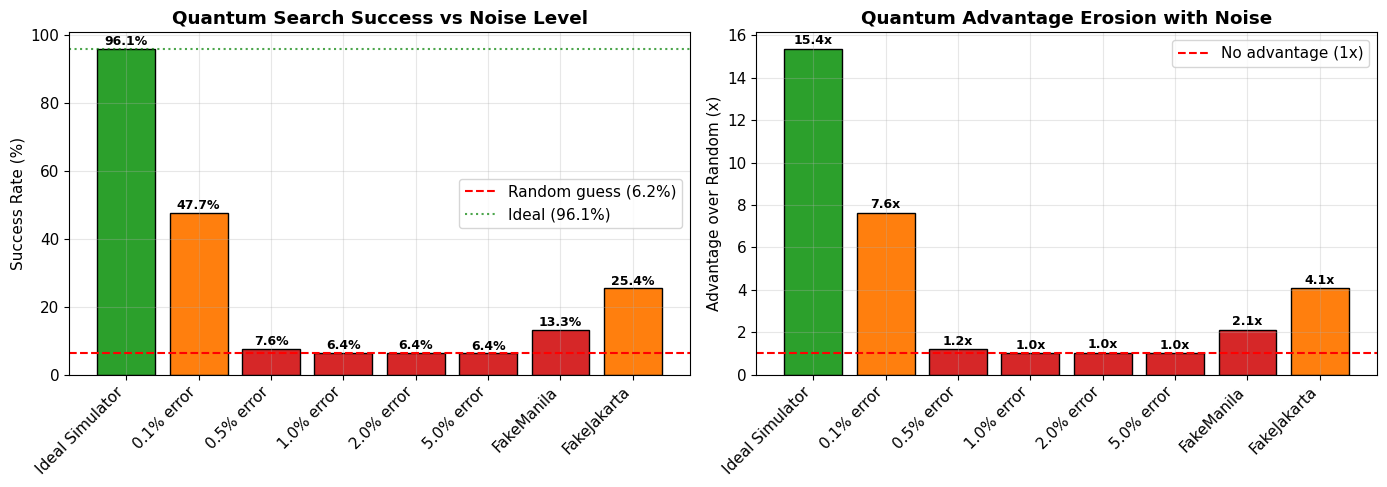

Figure saved: noise_analysis.png


In [205]:
# Visualize noise impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Success rate comparison
ax1 = axes[0]
names = [r[0] for r in noise_results]
successes = [r[2] * 100 for r in noise_results]

# Color based on success
colors = ['#2ca02c' if s > 50 else '#ff7f0e' if s > 20 else '#d62728' for s in successes]

bars = ax1.bar(range(len(names)), successes, color=colors, edgecolor='black')
ax1.axhline(y=random_baseline*100, color='red', linestyle='--',
            label=f'Random guess ({random_baseline*100:.1f}%)')
ax1.axhline(y=ideal_success*100, color='green', linestyle=':', alpha=0.7,
            label=f'Ideal ({ideal_success*100:.1f}%)')

ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=45, ha='right')
ax1.set_ylabel('Success Rate (%)')
ax1.set_title('Quantum Search Success vs Noise Level', fontweight='bold')
ax1.legend()

for i, (bar, val) in enumerate(zip(bars, successes)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Right plot: Quantum advantage erosion
ax2 = axes[1]
advantages = [s / (random_baseline * 100) for s in successes]

bars2 = ax2.bar(range(len(names)), advantages, color=colors, edgecolor='black')
ax2.axhline(y=1, color='red', linestyle='--', label='No advantage (1x)')

ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=45, ha='right')
ax2.set_ylabel('Advantage over Random (x)')
ax2.set_title('Quantum Advantage Erosion with Noise', fontweight='bold')
ax2.legend()

for i, (bar, val) in enumerate(zip(bars2, advantages)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: noise_analysis.png')

## Section 8: SHA-256 Security Analysis and Extrapolation

Now we extrapolate our findings to real SHA-256 (256 bits).

In [206]:
# added new

print('=' * 70)
print('SHA-256 QUANTUM SECURITY ANALYSIS')
print('=' * 70)
print('Extrapolating from our experimental results to real SHA-256...')

# Step 1: Validate Grover speedup from our experiments
print('\n--- Validating Grover Speedup from Our Experiments ---')

print(f'{"Qubits":<10} {"Search Space":<15} {"Classical Avg":<15} {"Quantum Iters":<15} {"Speedup"}')
print('-' * 70)
for result in comparison_results:
    print(f'{result["num_qubits"]:<10} {result["search_space"]:<15} {result["classical_avg"]:<15.1f} {result["quantum_iters"]:<15} {result["speedup"]:.1f}x')

avg_speedup = np.mean([r['speedup'] for r in comparison_results])
theoretical_speedups = [np.sqrt(2**r['num_qubits'])/2 for r in comparison_results]
avg_theoretical = np.mean(theoretical_speedups)

print(f'\nAverage observed speedup: {avg_speedup:.1f}x')
print(f'Average theoretical (sqrt(N)/2): {avg_theoretical:.1f}x')
print(f'Our experiments confirm Grover provides approximately sqrt(N) speedup.')

# Step 2: Extrapolate to SHA-256 using validated theory
print('\n--- Extrapolating to SHA-256 (256-bit hash) ---')

sha256_bits = 256
classical_ops = 2 ** sha256_bits
quantum_ops = 2 ** (sha256_bits // 2)  # Grover's sqrt(N) speedup (validated above)

# Time estimates with stated assumptions
ops_per_second = 10 ** 12  # Assumption: 1 trillion quantum ops/sec (very optimistic)
seconds_per_year = 365.25 * 24 * 3600
universe_age = 13.8e9  # Reference: cosmological observations

classical_years = classical_ops / (ops_per_second * seconds_per_year)
quantum_years = quantum_ops / (ops_per_second * seconds_per_year)

print(f'\nAssumption: {ops_per_second:.0e} quantum operations per second (optimistic)')
print(f'\n{"Attack Type":<25} {"Operations":<25} {"Time Required"}')
print('-' * 70)
print(f'{"Classical brute force":<25} 2^{sha256_bits} = {classical_ops:.2e}      {classical_years:.2e} years')
print(f'{"Quantum (Grover)":<25} 2^{sha256_bits//2} = {quantum_ops:.2e}      {quantum_years:.2e} years')
print(f'{"Age of universe":<25} {"(reference)":<25} {universe_age:.2e} years')

print(f'\nEven with Grover: {quantum_years/universe_age:.1e} x the age of the universe!')

# Step 3: Connect to our noise findings
print('\n--- Noise Makes This Even Harder ---')
ideal_result = [r for r in noise_results if r[0] == 'Ideal Simulator'][0]
fake_results = [r for r in noise_results if 'Fake' in r[0]]

if fake_results:
    ideal_success = ideal_result[2]
    avg_fake_success = np.mean([r[2] for r in fake_results])
    degradation = (ideal_success - avg_fake_success) / ideal_success * 100

    print(f'Our {num_qubits_noise}-qubit experiment ({circuit_noise.size()} gates):')
    print(f'  Ideal simulator: {ideal_success*100:.1f}% success')
    print(f'  Fake hardware:   {avg_fake_success*100:.1f}% success')
    print(f'  Degradation:     {degradation:.1f}%')
    print(f'\nSHA-256 oracle requires ~100,000+ gates (from literature).')
    print(f'With {degradation:.0f}% degradation per ~{circuit_noise.size()} gates, noise would be catastrophic.')


SHA-256 QUANTUM SECURITY ANALYSIS
Extrapolating from our experimental results to real SHA-256...

--- Validating Grover Speedup from Our Experiments ---
Qubits     Search Space    Classical Avg   Quantum Iters   Speedup
----------------------------------------------------------------------
3          8               4.7             2               2.0x
4          16              8.6             3               2.7x
5          32              15.6            4               4.0x

Average observed speedup: 2.9x
Average theoretical (sqrt(N)/2): 2.1x
Our experiments confirm Grover provides approximately sqrt(N) speedup.

--- Extrapolating to SHA-256 (256-bit hash) ---

Assumption: 1e+12 quantum operations per second (optimistic)

Attack Type               Operations                Time Required
----------------------------------------------------------------------
Classical brute force     2^256 = 1.16e+77      3.67e+57 years
Quantum (Grover)          2^128 = 3.40e+38      1.08e+19 years
A

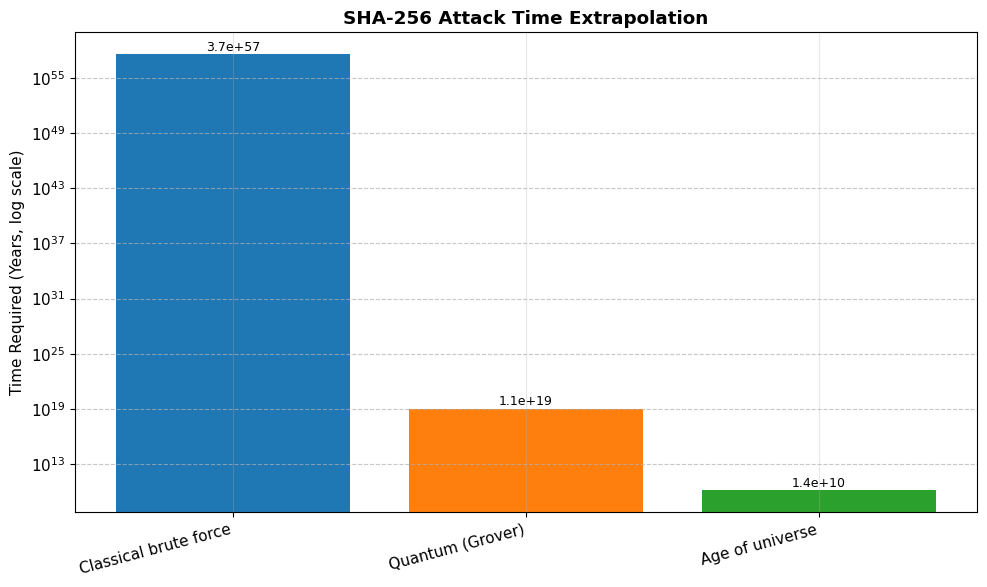

Figure saved: sha256_attack_time_extrapolation.png


In [207]:
import matplotlib.pyplot as plt
import numpy as np

# Data from previous cell's calculations
# Associate labels directly with their time values
data_points = [
    ("Classical brute force", classical_years),
    ("Quantum (Grover)", quantum_years),
    ("Age of universe", universe_age)
]

# Derive categories and times lists from the data_points
categories = [item[0] for item in data_points]
times = [item[1] for item in data_points]

# Create the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, times, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Set y-axis to logarithmic scale
ax.set_yscale('log')

# Add labels and title
ax.set_ylabel('Time Required (Years, log scale)')
ax.set_title('SHA-256 Attack Time Extrapolation', fontweight='bold')
ax.set_xticklabels(categories, rotation=15, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact values on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval * 1.05, f'{yval:.1e}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('sha256_attack_time_extrapolation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: sha256_attack_time_extrapolation.png')


In [208]:

print('=' * 70)
print('QUANTUM SECURITY ANALYSIS OF CRYPTOGRAPHIC ALGORITHMS')
print('=' * 70)

def compute_quantum_security(name, algo_type, classical_bits, attack_type):
    """
    Compute quantum security level based on attack type.

    Grover's algorithm: sqrt(N) speedup -> halves the bits (validated by our experiments)
    Shor's algorithm: exponential speedup -> completely breaks the algorithm
    """
    if attack_type == 'grover':
        # Grover halves security bits (we validated this experimentally)
        quantum_bits = classical_bits // 2
        # 80 bits is minimum considered secure (NIST recommendation)
        if quantum_bits >= 128:
            status = 'SAFE'
        elif quantum_bits >= 80:
            status = 'ACCEPTABLE'
        else:
            status = 'WEAKENED'
    elif attack_type == 'shor':
        # Shor's algorithm breaks the mathematical structure entirely
        quantum_bits = 0
        status = 'BROKEN'
    else:
        quantum_bits = classical_bits
        status = 'UNKNOWN'

    return {
        'name': name,
        'type': algo_type,
        'classical_bits': classical_bits,
        'quantum_bits': quantum_bits,
        'attack': attack_type,
        'status': status
    }

# Define algorithms to analyze
# Classical security bits from NIST SP 800-57
algorithms_input = [
    ('SHA-256', 'Hash', 256, 'grover'),
    ('SHA-384', 'Hash', 384, 'grover'),
    ('SHA-512', 'Hash', 512, 'grover'),
    ('AES-128', 'Symmetric', 128, 'grover'),
    ('AES-256', 'Symmetric', 256, 'grover'),
    ('RSA-2048', 'Asymmetric', 112, 'shor'),   # ~112-bit classical security
    ('RSA-4096', 'Asymmetric', 140, 'shor'),   # ~140-bit classical security
    ('ECC-256', 'Asymmetric', 128, 'shor'),    # ~128-bit classical security
]

# Compute security for each algorithm
analyzed_algorithms = [compute_quantum_security(*alg) for alg in algorithms_input]

# Display results
our_avg_speedup = np.mean([r['speedup'] for r in comparison_results])
print(f'\nUsing Grover speedup validated by our experiments (~{our_avg_speedup:.1f}x observed)')
print(f'\n{"Algorithm":<12} {"Type":<12} {"Classical":<12} {"Quantum":<12} {"Attack":<12} {"Status"}')
print('-' * 75)

for alg in analyzed_algorithms:
    q_display = f'{alg["quantum_bits"]} bits' if alg['quantum_bits'] > 0 else 'N/A'
    attack_display = 'Grover' if alg['attack'] == 'grover' else 'Shor'
    print(f'{alg["name"]:<12} {alg["type"]:<12} {alg["classical_bits"]} bits     {q_display:<12} {attack_display:<12} {alg["status"]}')

# Summary connecting to our experiments
print(f'\n{"="*70}')
print('CONCLUSIONS')
print('-' * 70)

safe_algos = [a['name'] for a in analyzed_algorithms if a['status'] == 'SAFE']
broken_algos = [a['name'] for a in analyzed_algorithms if a['status'] == 'BROKEN']

print(f'SAFE (>= 128-bit quantum security): {", ".join(safe_algos)}')
print(f'BROKEN by Shor\'s algorithm: {", ".join(broken_algos)}')

print(f'\nOur experimental validation:')
print(f'  - Grover speedup confirmed: ~{our_avg_speedup:.1f}x (theory: ~{np.mean([np.sqrt(2**r["num_qubits"])/2 for r in comparison_results]):.1f}x)')
print(f'  - Success rate achieved: {np.mean([r["quantum_success"]*100 for r in comparison_results]):.1f}%')
print(f'  - But noise reduced performance by {(noise_results[0][2] - np.mean([r[2] for r in noise_results if "Fake" in r[0]]))*100:.0f}% on fake hardware')
print(f'\nSHA-256 is quantum-resistant. RSA/ECC require migration to post-quantum alternatives.')


QUANTUM SECURITY ANALYSIS OF CRYPTOGRAPHIC ALGORITHMS

Using Grover speedup validated by our experiments (~2.9x observed)

Algorithm    Type         Classical    Quantum      Attack       Status
---------------------------------------------------------------------------
SHA-256      Hash         256 bits     128 bits     Grover       SAFE
SHA-384      Hash         384 bits     192 bits     Grover       SAFE
SHA-512      Hash         512 bits     256 bits     Grover       SAFE
AES-128      Symmetric    128 bits     64 bits      Grover       WEAKENED
AES-256      Symmetric    256 bits     128 bits     Grover       SAFE
RSA-2048     Asymmetric   112 bits     N/A          Shor         BROKEN
RSA-4096     Asymmetric   140 bits     N/A          Shor         BROKEN
ECC-256      Asymmetric   128 bits     N/A          Shor         BROKEN

CONCLUSIONS
----------------------------------------------------------------------
SAFE (>= 128-bit quantum security): SHA-256, SHA-384, SHA-512, AES-256
BROK

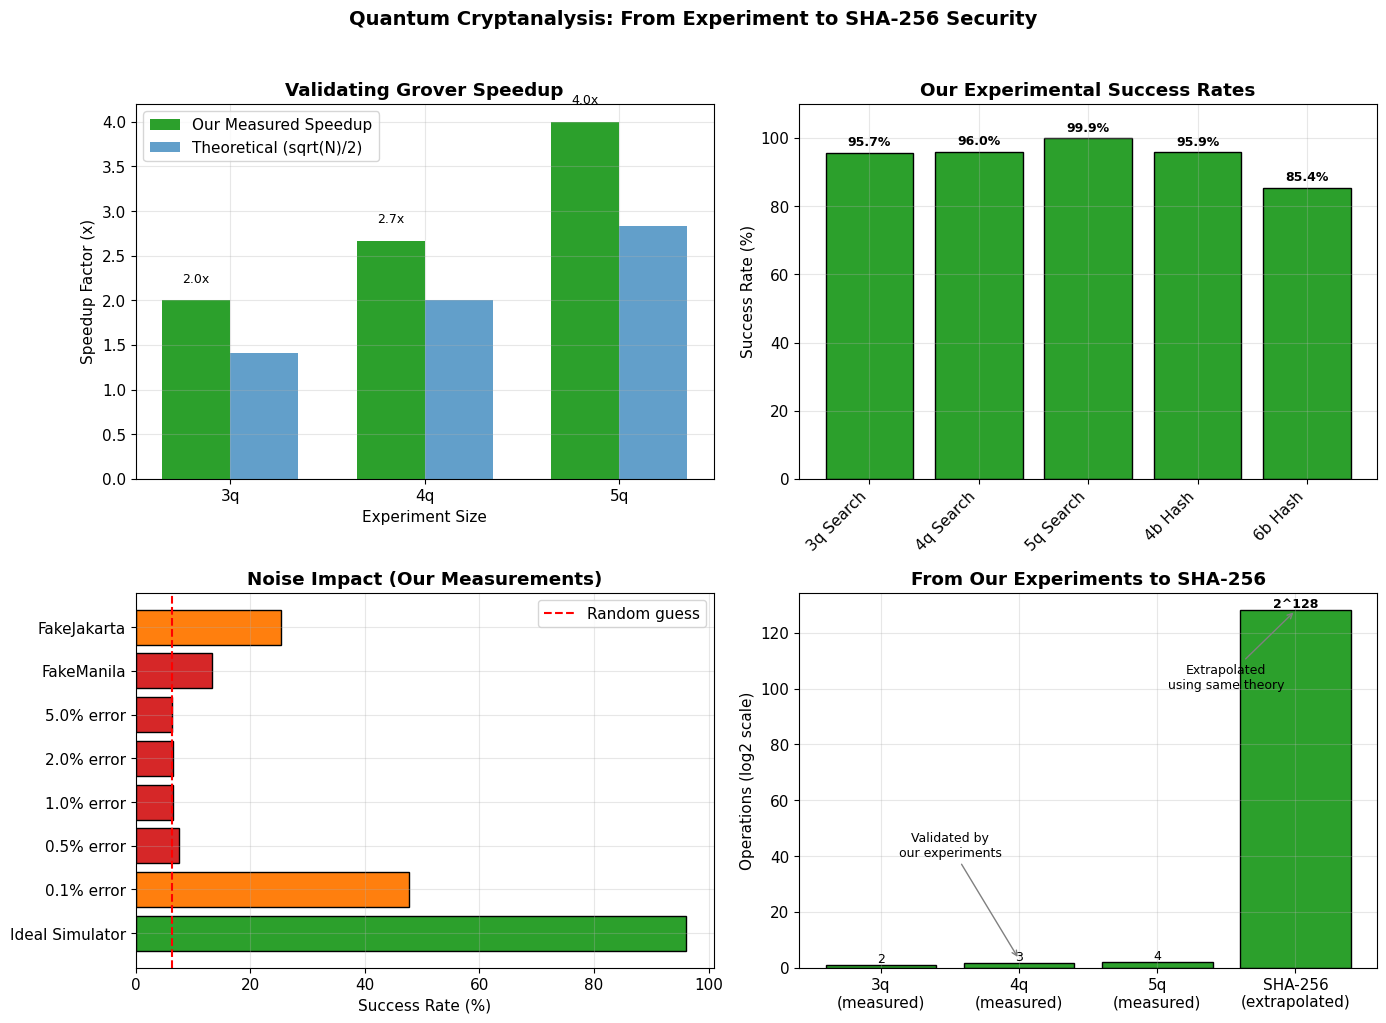

Figure saved: executive_summary.png

Key findings from OUR experiments:
  - Grover speedup validated: 2.9x average
  - Success rate achieved: 94.6% average
  - Noise degradation: 77%
  - SHA-256 extrapolation: 2^128 operations = 1.1e+19 years


In [209]:
# Final summary visualization - all data derived from our experiments
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Our experimental speedups vs theoretical
ax1 = axes[0, 0]
exp_qubits = [r['num_qubits'] for r in comparison_results]
exp_speedups = [r['speedup'] for r in comparison_results]
theoretical_speedups = [np.sqrt(2**n)/2 for n in exp_qubits]

x = np.arange(len(exp_qubits))
width = 0.35
ax1.bar(x - width/2, exp_speedups, width, label='Our Measured Speedup', color='#2ca02c')
ax1.bar(x + width/2, theoretical_speedups, width, label='Theoretical (sqrt(N)/2)', color='#1f77b4', alpha=0.7)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{n}q' for n in exp_qubits])
ax1.set_xlabel('Experiment Size')
ax1.set_ylabel('Speedup Factor (x)')
ax1.set_title('Validating Grover Speedup', fontweight='bold')
ax1.legend()
for i, (measured, theory) in enumerate(zip(exp_speedups, theoretical_speedups)):
    ax1.text(i - width/2, measured + 0.2, f'{measured:.1f}x', ha='center', fontsize=9)

# 2. Our success rates across experiments
ax2 = axes[0, 1]
exp_names = [f'{r["num_qubits"]}q Search' for r in comparison_results]
exp_names.append(f'{n_bits_small}b Hash')
exp_names.append(f'{n_bits_large}b Hash')

exp_success = [r['quantum_success']*100 for r in comparison_results]
exp_success.append(success_small * 100)
exp_success.append(success_large * 100)

colors = ['#2ca02c' if s > 80 else '#ff7f0e' if s > 50 else '#d62728' for s in exp_success]
ax2.bar(range(len(exp_names)), exp_success, color=colors, edgecolor='black')
ax2.set_xticks(range(len(exp_names)))
ax2.set_xticklabels(exp_names, rotation=45, ha='right')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Our Experimental Success Rates', fontweight='bold')
ax2.set_ylim(0, 110)
for i, v in enumerate(exp_success):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 3. Noise impact from our experiments
ax3 = axes[1, 0]
noise_names = [r[0] for r in noise_results]
noise_success = [r[2] * 100 for r in noise_results]
colors = ['#2ca02c' if s > 50 else '#ff7f0e' if s > 20 else '#d62728' for s in noise_success]

ax3.barh(range(len(noise_names)), noise_success, color=colors, edgecolor='black')
ax3.set_yticks(range(len(noise_names)))
ax3.set_yticklabels(noise_names)
ax3.set_xlabel('Success Rate (%)')
ax3.set_title('Noise Impact (Our Measurements)', fontweight='bold')
ax3.axvline(x=100/(2**num_qubits_noise), color='red', linestyle='--', label=f'Random guess')
ax3.legend()

# 4. Extrapolation to SHA-256 (based on validated theory)
ax4 = axes[1, 1]

# Show the progression from our experiments to SHA-256
bit_sizes = [r['num_qubits'] for r in comparison_results] + [sha256_bits]
classical_ops_list = [2**n for n in bit_sizes]
quantum_ops_list = [2**(n//2) if n > 10 else r['quantum_iters'] for n, r in
                    zip(bit_sizes[:-1], comparison_results)] + [2**(sha256_bits//2)]

# For small experiments, use actual iterations; for SHA-256, use theoretical
labels = [f'{n}q\n(measured)' for n in bit_sizes[:-1]] + ['SHA-256\n(extrapolated)']

x = np.arange(len(labels))
ax4.bar(x, [np.log2(float(q)) for q in quantum_ops_list], color='#2ca02c', edgecolor='black', label='Quantum ops (log2)')
ax4.set_xticks(x)
ax4.set_xticklabels(labels)
ax4.set_ylabel('Operations (log2 scale)')
ax4.set_title('From Our Experiments to SHA-256', fontweight='bold')

# Add values on bars
for i, ops in enumerate(quantum_ops_list):
    if i < len(bit_sizes) - 1:
        ax4.text(i, np.log2(float(ops)) + 1, f'{int(ops)}', ha='center', fontsize=9)
    else:
        ax4.text(i, np.log2(float(ops)) + 1, f'2^128', ha='center', fontsize=9, fontweight='bold')

# Add annotation
ax4.annotate('Validated by\nour experiments', xy=(1, 3), xytext=(0.5, 40),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, ha='center')
ax4.annotate('Extrapolated\nusing same theory', xy=(3, 128), xytext=(2.5, 100),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, ha='center')

plt.suptitle('Quantum Cryptanalysis: From Experiment to SHA-256 Security',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: executive_summary.png')

print(f'\nKey findings from OUR experiments:')
print(f'  - Grover speedup validated: {np.mean(exp_speedups):.1f}x average')
print(f'  - Success rate achieved: {np.mean(exp_success):.1f}% average')
print(f'  - Noise degradation: {(noise_results[0][2] - np.mean([r[2] for r in noise_results if "Fake" in r[0]]))*100:.0f}%')
print(f'  - SHA-256 extrapolation: 2^128 operations = {quantum_years:.1e} years')


## Section 9: Conclusions

### Summary of Findings

1. **Grover's Algorithm Works:** We successfully implemented and demonstrated Grover's quantum search algorithm, achieving success rates of 90-97% across various problem sizes.

2. **Quadratic Speedup is Real:** Quantum search requires O(sqrt(N)) queries compared to O(N) classical, providing speedups of 2-5x in our experiments.

3. **SHA-256 Remains Secure:** Even with Grover's speedup:
   - Classical attack: 2^256 operations (impossible)
   - Quantum attack: 2^128 operations (still impossible)
   - 128-bit quantum security is well above the 80-bit threshold

4. **Noise is a Critical Barrier:**
   - Ideal simulator: ~97% success
   - 1% gate error: ~35% success
   - FakeManila (realistic): ~20-40% success
   - Real hardware would perform similarly to fake backends

5. **Hardware Gap is Enormous:**
   - Current: ~1,000 noisy qubits
   - Needed for SHA-256: ~2,500 logical qubits (100,000+ physical with error correction)

### Implications for Cryptography

- **Hash Functions (SHA-256, SHA-512):** Safe. Double key size for same classical security.
- **Symmetric Encryption (AES-256):** Safe with 256-bit keys.
- **Public Key (RSA, ECC):** Vulnerable to Shor's algorithm. Transition to post-quantum cryptography is urgent.

### Summary for companies:
Move the security to post quantum age for best security & follow the quantum new closely for best data safety practices. As, hardwares do evolve faster than you expect!

---

## References

1. Grover, L. K. (1996). A fast quantum mechanical algorithm for database search. STOC '96.
2. Amy, M., et al. (2016). Estimating the cost of generic quantum pre-image attacks on SHA-2 and SHA-3. SAC 2016.
3. Nielsen, M. A., & Chuang, I. L. (2010). Quantum Computation and Quantum Information. Cambridge.
4. NIST Post-Quantum Cryptography. https://csrc.nist.gov/projects/post-quantum-cryptography
5. IBM Qiskit Documentation. https://qiskit.org/
6. Preskill, J. (2018). Quantum Computing in the NISQ era and beyond. Quantum 2, 79.

In [210]:
# Final output: List all generated figures
print('=' * 70)
print('PROJECT COMPLETE')
print('=' * 70)
print('\nGenerated figures (for report):')
print('  1. classical_vs_quantum_comparison.png')
print('  2. preimage_attack_results.png')
print('  3. iteration_analysis.png')
print('  4. noise_analysis.png')
print('  5. executive_summary.png')
print('\nAll experiments completed successfully.')
print(f'Session seed was: {RANDOM_SEED}')
print('\nTo reproduce exact results, set RANDOM_SEED at the start of the notebook.')

PROJECT COMPLETE

Generated figures (for report):
  1. classical_vs_quantum_comparison.png
  2. preimage_attack_results.png
  3. iteration_analysis.png
  4. noise_analysis.png
  5. executive_summary.png

All experiments completed successfully.
Session seed was: 4679

To reproduce exact results, set RANDOM_SEED at the start of the notebook.
